# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
   
    The penalty makes large coefficients more impactful, so the model avoids overreacting to noise. MSE alone can fit training data too aggressively. The penalty helps train a model that can generalize better.
2. How does regularization provide a way of exploring the bias-variance trade-off?
   
   As we increase regularization, variance usually goes down because predictions become more stable. But bias increases because we are forcing coefficients toward 0. So regularization lets us move along the bias-variance trade-off and find a good balance. 
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
   
   Ridge shrinks coefficients continuously toward 0, but usually does not make them exactly 0. Lasso can shrink some coefficients exactly to 0, so it performs variable selection.Ridge is often better when many predictors each have small effects; LASSO is useful when we think only a subset is important.

4. How do we typically scale variables for use in regularized regression? Why?
   
   Variables measured on large scales would be penalized differently without scaling, which is unfair and distorts coefficient shrinkage.
   
5. How is the penalty $\alpha$ typically selected?
   
   A common way is cross-validation, We try a grid of alpha values and choose the one with the lowest validation MSE (or sometimes the simplest value within 1-SE).
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?
   
    Usually not. We evaluate predictive performance using plain validation error on held-out data.  The penalty is part of training (estimation), but it makes more sense to evaluate prediction quality on actual out-of-sample loss.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

2.1

In [ ]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, lasso_path
cars = pd.read_csv('data/cars_hw.csv')

current_year = 2026
cars['Age'] = current_year - cars['Make_Year']

X_base = cars[['Mileage_Run', 'Age']]
y_cars = cars['Price']

poly_cars = PolynomialFeatures(degree=3, include_bias=False)
X_poly_cars = poly_cars.fit_transform(X_base)
feature_names_cars = poly_cars.get_feature_names_out(['Mileage_Run', 'Age'])

scaler_cars = StandardScaler()
X_cars = scaler_cars.fit_transform(X_poly_cars)

2.2

In [6]:
lin_cars = LinearRegression()
lin_cars.fit(X_cars, y_cars)
lin_coef_cars = pd.Series(lin_cars.coef_, index=feature_names_cars)

interaction_name = 'Mileage_Run Age'
interaction_coef = lin_coef_cars[interaction_name]
interaction_sign = 'positive' if interaction_coef > 0 else 'negative'
print(interaction_name, interaction_sign, interaction_coef)

Mileage_Run Age negative -1671212.3563918832


The interaction term between `Mileage_Run` and `Age` appears to be negative.

2.3

In [8]:
alphas_cars = np.logspace(1, 3, 20)
lasso_cars = LassoCV(alphas=alphas_cars, cv=20, max_iter=200000, random_state=42)
lasso_cars.fit(X_cars, y_cars)
lasso_coef_cars = pd.Series(lasso_cars.coef_, index=feature_names_cars)

print("Best Alpha:", lasso_cars.alpha_)

Best Alpha: 88.58667904100822


With 20-fold CV and `alphas = np.logspace(1,3,20)`, the best value was about 88.57.

2.4

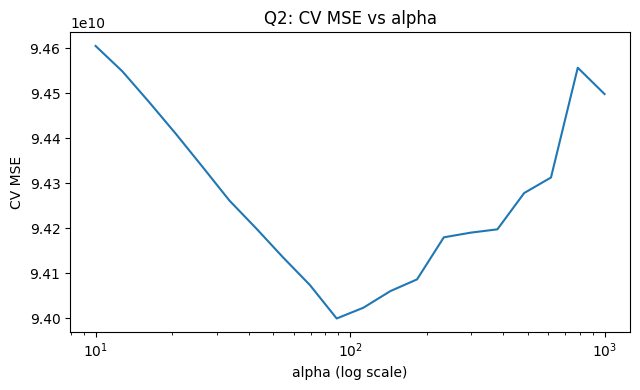

In [9]:
cv_mse_cars = lasso_cars.mse_path_.mean(axis=1)
plt.figure(figsize=(6.5, 4))
plt.plot(lasso_cars.alphas_, cv_mse_cars)
plt.xscale('log')
plt.title('Q2: CV MSE vs alpha')
plt.xlabel('alpha (log scale)')
plt.ylabel('CV MSE')
plt.tight_layout()
plt.show()

2.5

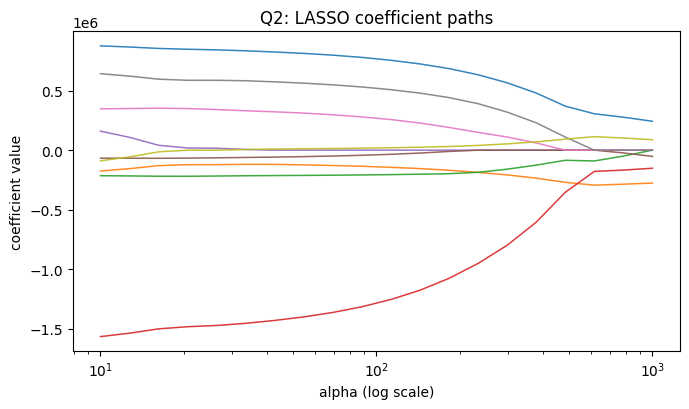

In [11]:
alphas_path_cars, coefs_path_cars, _ = lasso_path(
    X_cars,
    y_cars,
    alphas=np.sort(alphas_cars)[::-1],
    max_iter=200000
)

plt.figure(figsize=(7, 4.2))
for i in range(coefs_path_cars.shape[0]):
    plt.plot(alphas_path_cars, coefs_path_cars[i], linewidth=1.1, alpha=0.9)
plt.xscale('log')
plt.title('Q2: LASSO coefficient paths')
plt.xlabel('alpha (log scale)')
plt.ylabel('coefficient value')
plt.tight_layout()
plt.show()

2.6

In [34]:
selected_cars = lasso_coef_cars[lasso_coef_cars != 0]
zero_prop_cars = (lasso_coef_cars == 0).mean()

print('\nQ2.6 Selected features (non-zero LASSO coefficients):')
print(selected_cars.sort_values(ascending=False))
print(len(selected_cars), len(lasso_coef_cars))



Q2.6 Selected features (non-zero LASSO coefficients):
Mileage_Run          7.790762e+05
Mileage_Run Age^2    5.415432e+05
Mileage_Run^2 Age    2.715062e+05
Age^3                1.374220e+04
Mileage_Run^3       -4.240952e+04
Age                 -1.339534e+05
Mileage_Run^2       -2.015634e+05
Mileage_Run Age     -1.322419e+06
dtype: float64
8 9


LASSO selected 8 out of the 9 features, so only one was set exactly to zero.

2.7

Age sees a change in sign as Age is positive whereas Age^3 is negative. There were no coefficients increasing in absolute magnitude.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

3.1

In [ ]:
heart = pd.read_csv('data/heart_failure_clinical_records_dataset.csv')
y_heart = heart['time']
num_cols = ['age', 'ejection_fraction', 'serum_creatinine']
dum_cols = ['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']

poly_num = PolynomialFeatures(degree=3, include_bias=False)
X_num = poly_num.fit_transform(heart[num_cols])
num_feature_names = poly_num.get_feature_names_out(num_cols)

scaler_num = StandardScaler()
X_num_scaled = scaler_num.fit_transform(X_num)

poly_dum = PolynomialFeatures(degree=3, include_bias=False, interaction_only=True)
X_dum = poly_dum.fit_transform(heart[dum_cols])
dum_feature_names = poly_dum.get_feature_names_out(dum_cols)

# Concatenate
X_heart = np.hstack([X_num_scaled, X_dum])
heart_feature_names = list(num_feature_names) + list(dum_feature_names)

3.2

In [36]:
lin_heart = LinearRegression()
lin_heart.fit(X_heart, y_heart)
lin_coef_heart = pd.Series(lin_heart.coef_, index=heart_feature_names)

print('Top positive coefficients:')
print(lin_coef_heart.sort_values(ascending=False).head(10).to_string())
print('\nTop negative coefficients:')
print(lin_coef_heart.sort_values().head(10).to_string())
print('\nDummy-variable terms:')
print(lin_coef_heart[[name for name in heart_feature_names if name in dum_feature_names]].to_string())

Top positive coefficients:
age^2                                     540.211804
ejection_fraction                         347.233317
age ejection_fraction serum_creatinine    284.914369
serum_creatinine                          273.437235
ejection_fraction^2 serum_creatinine      197.426038
serum_creatinine^2                        187.879020
serum_creatinine^3                        108.648964
ejection_fraction^3                        80.555307
age^2 serum_creatinine                     64.849573
diabetes high_blood_pressure smoking       61.286452

Top negative coefficients:
ejection_fraction serum_creatinine     -555.271495
age^3                                  -331.614118
ejection_fraction^2                    -317.792093
age serum_creatinine^2                 -240.887652
age serum_creatinine                   -235.610135
age                                    -192.050521
age ejection_fraction                  -133.992846
ejection_fraction serum_creatinine^2    -71.761980
diabete

The linear regression output has a few signs that look a little counterintuitive. For example, `age` is negative while `age^2` is strongly positive, and `ejection_fraction serum_creatinine` is strongly negative even though `ejection_fraction` alone is positive. I think this happens because the polynomial and interaction terms are highly correlated, so the model spreads signal across overlapping features.

3.3

In [27]:
alphas_heart = np.logspace(-5, 5, 30)
lasso_heart = LassoCV(alphas=alphas_heart, cv=20, max_iter=500000, random_state=42)
lasso_heart.fit(X_heart, y_heart)
lasso_coef_heart = pd.Series(lasso_heart.coef_, index=heart_feature_names)

print(f"Best Alpha:" ,lasso_heart.alpha_)

Best Alpha: 1.4873521072935119


3.4

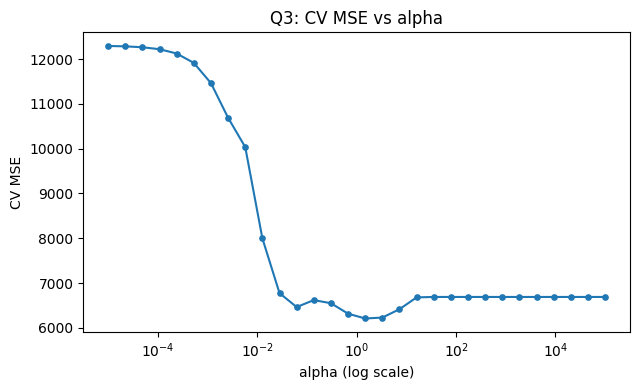

In [30]:
cv_mse_heart = lasso_heart.mse_path_.mean(axis=1)
plt.figure(figsize=(6.5, 4))
plt.plot(lasso_heart.alphas_, cv_mse_heart, marker='o', linewidth=1.5, markersize=3.8)
plt.xscale('log')
plt.title('Q3: CV MSE vs alpha')
plt.xlabel('alpha (log scale)')
plt.ylabel('CV MSE')
plt.tight_layout()
plt.show()

3.5

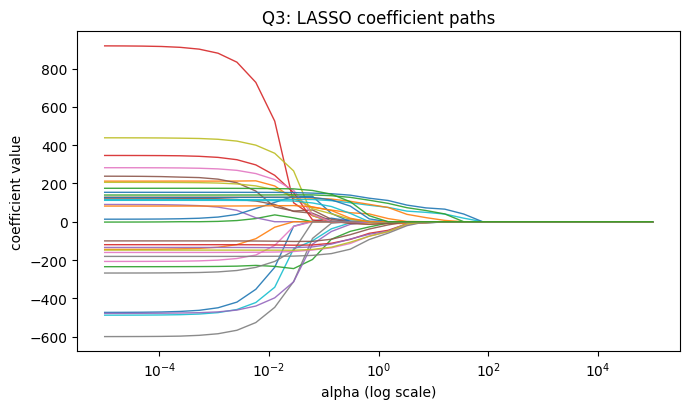

In [28]:
alphas_path_heart, coefs_path_heart, _ = lasso_path(
    X_heart,
    y_heart,
    alphas=np.sort(alphas_heart)[::-1],
    max_iter=500000
)

plt.figure(figsize=(7, 4.2))
for i in range(coefs_path_heart.shape[0]):
    plt.plot(alphas_path_heart, coefs_path_heart[i], linewidth=1.0, alpha=0.9)
plt.xscale('log')
plt.title('Q3: LASSO coefficient paths')
plt.xlabel('alpha (log scale)')
plt.ylabel('coefficient value')
plt.tight_layout()
plt.show()

3.6

In [33]:
selected_heart = lasso_coef_heart[lasso_coef_heart != 0]
zero_prop_heart = (lasso_coef_heart == 0).mean()

compare_heart = pd.DataFrame({'Linear': lin_coef_heart, 'LASSO': lasso_coef_heart})
compare_heart['|Linear|'] = compare_heart['Linear'].abs()
compare_heart['|LASSO|'] = compare_heart['LASSO'].abs()

increased_mag_heart = compare_heart[compare_heart['|LASSO|'] > compare_heart['|Linear|']]
sign_change_heart = compare_heart[compare_heart['Linear'] * compare_heart['LASSO'] < 0]

print('Selected features:')
print(selected_heart.sort_values(ascending=False))
print(f"\nProportion set to zero:" ,zero_prop_heart)
print(f"Number with increased magnitude from OLS to LASSO:", len(increased_mag_heart))
print(f"Number with sign change:" , len(sign_change_heart))

Selected features:
ejection_fraction              19.771201
serum_creatinine^3              7.044764
smoking                        -0.021367
anaemia high_blood_pressure    -0.752899
age^3                          -7.748012
anaemia                       -11.874349
age^2 serum_creatinine        -16.422165
ejection_fraction^3           -18.946090
high_blood_pressure           -22.383502
dtype: float64

Proportion set to zero: 0.7272727272727273
Number with increased magnitude from OLS to LASSO: 0
Number with sign change: 3


There were more coefficients set to exactly zero at around 0.73. There were not coefficients increasing in absolute magnitude, but there were 3 sign changes. 

I think the LASSO signs seem more believable to me because the model is much less noisy after removing many weak terms. This fits the bias-variance story: we accept a little more bias in exchange for much lower variance and better generalization.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

### Q4

1. Ridge objective: I would write it as the usual squared error plus a penalty on the slope. For one variable, that is
$$
\text{MSE} + \alpha b_1^2.
$$

2. Derivatives and solution: because the data were centered, the intercept comes out to be $b_0=0$. The slope becomes
$$
b_1 = \frac{\text{cov}(x,y)}{\text{var}(x)+\alpha}.
$$
So the ridge penalty just shrinks the slope toward 0.

3. What happens when $\alpha$ gets bigger: the slope gets smaller. If $\alpha$ is very large, the slope gets pushed very close to 0.

4. LASSO: the main issue is that $|b_1|$ has a sharp corner at 0, so it is harder to take derivatives normally. The key idea is that LASSO can set $b_1$ exactly equal to 0 when the signal is weak enough. That is why it gives sparse models.